In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import os
import pickle
cur_dir = os.getcwd()
cost= 0.037

In [2]:
result_path = os.path.join(cur_dir,'results')
figure_path = os.path.join(cur_dir, 'plots')
print(figure_path)

/Users/florencer/git/EE_synthetic/figures/plots


In [3]:
def load_experiment(filename):
    with open(filename, "rb") as f:
        training_log_dict = pickle.load(f)
    return training_log_dict
        
def load_experiment_of_cost(baseline, cost):
    filename = os.path.join(result_path, f"{baseline}{cost}_k5__training_result.pkl")
    print(filename)
    return load_experiment(filename)


In [4]:
# filename = os.path.join(result_path, f'new2_multi_2s_exp{cost}_k5__training_result.pkl')
# training_log_dict = load_experiment(filename)
training_log_dict = load_experiment_of_cost('softr_risk', 0.03)

/Users/florencer/git/EE_synthetic/figures/results/softr_risk0.03_k5__training_result.pkl


FileNotFoundError: [Errno 2] No such file or directory: '/Users/florencer/git/EE_synthetic/figures/results/softr_risk0.03_k5__training_result.pkl'

In [5]:
print(training_log_dict.keys())

NameError: name 'training_log_dict' is not defined

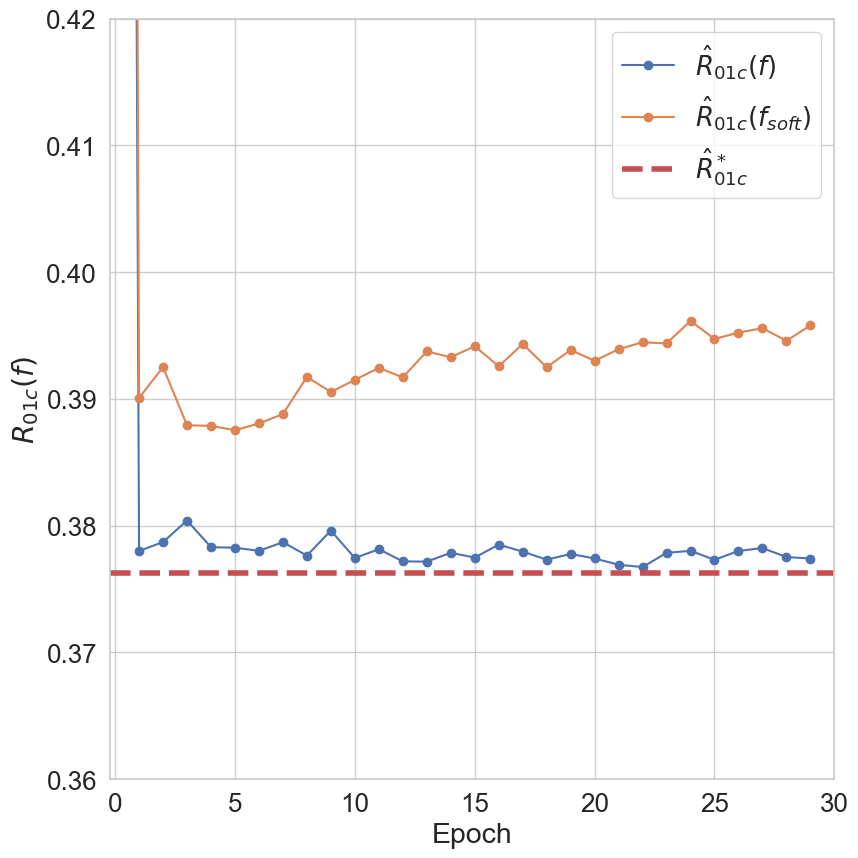

[tensor(0.8000), tensor(0.3780), tensor(0.3787), tensor(0.3804), tensor(0.3783), tensor(0.3783), tensor(0.3780), tensor(0.3787), tensor(0.3776), tensor(0.3796), tensor(0.3775), tensor(0.3781), tensor(0.3772), tensor(0.3772), tensor(0.3779), tensor(0.3775), tensor(0.3785), tensor(0.3780), tensor(0.3773), tensor(0.3778), tensor(0.3774), tensor(0.3769), tensor(0.3767), tensor(0.3779), tensor(0.3780), tensor(0.3773), tensor(0.3780), tensor(0.3782), tensor(0.3775), tensor(0.3774)]


In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 9))
sns.set_context("notebook", font_scale=1.7)
test_01c = training_log_dict['track_01c']
train_loss = training_log_dict['track_epoch_loss']
optimal_l01c = training_log_dict['optimal_l01c']
    
#plt.plot(train_loss, label=r'$\hat{R}_{hinge}(f)$', marker='o')   
#plt.plot(test_01c, label=r'$\hat{R}_{01c}(f_{sr})$', marker='o')
#plt.plot(ctc, label=r'$\hat{R}_{01c}(f_{ct})$', marker='o')
plt.plot(s2, label=r'$\hat{R}_{01c}(f)$', marker='o')
plt.plot(soft, label=r'$\hat{R}_{01c}(f_{soft})$', marker='o')
plt.axhline(y=optimal_l01c, color='r', linestyle='--', linewidth=4, label=r'$\hat{R}^*_{01c}$')
plt.xlim([-0.2,30])
plt.ylim([0.36,0.42])
plt.xlabel('Epoch')
plt.ylabel(r'$R_{01c}(f)$')
plt.legend()
plt.tight_layout()
plt.show()
#plt.savefig(os.path.join(figure_path, prefix+'R01c.pdf'))
plt.close()
print(test_01c)




In [19]:
# training_log_dict = load_experiment_of_cost('ctmatch_opt_rate_risk', 0.03)
# ct = training_log_dict['track_01c']
# training_log_dict = load_experiment_of_cost('2s_risk', 0.03)
# s2 = training_log_dict['track_01c']
# training_log_dict = load_experiment_of_cost('ctc_risk', 0.03)
# ctc = training_log_dict['track_01c']
# training_log_dict = load_experiment_of_cost('softr_risk', 0.03)
# sr = training_log_dict['track_01c']
training_log_dict = load_experiment_of_cost('softplus_risk', 0.07)
soft = training_log_dict['track_01c']
training_log_dict = load_experiment_of_cost('2s_risk', 0.07)
s2 = training_log_dict['track_01c']


/Users/florencer/git/EE_synthetic/figures/results/softplus_risk0.07_k5__training_result.pkl
/Users/florencer/git/EE_synthetic/figures/results/2s_risk0.07_k5__training_result.pkl


$soft$ 0.4091647803783417 0.0014432614824308034
$hinge$ 0.38371234238147733 0.000499252927892606


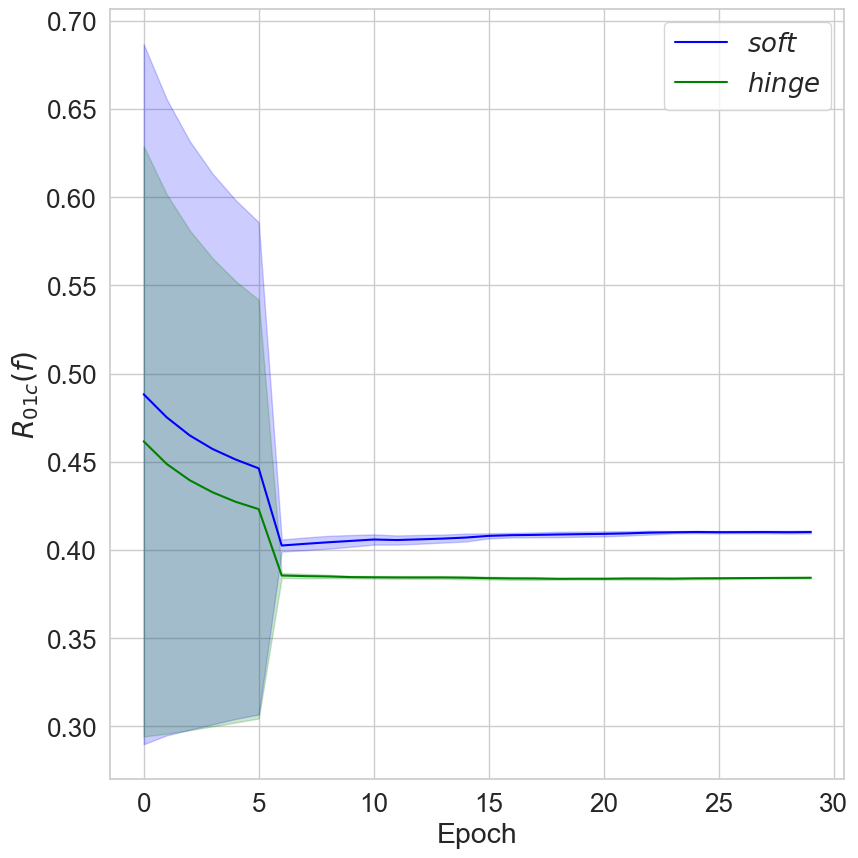

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def smooth_mean_std(y, window=10):
    y_series = pd.Series(y)
    mean = y_series.rolling(window=window, min_periods=1, center=True).mean()
    std = y_series.rolling(window=window, min_periods=1, center=True).std()
    return mean, std

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 9))
sns.set_context("notebook", font_scale=1.7)

# Extract data

optimal_l01c = training_log_dict['optimal_l01c']
epochs = np.arange(len(s2))

# Smooth and plot each curve with error bands
for data, label, color in zip(
    [soft, s2],
    [r'$soft$',  r'$hinge$'],
    ['blue', 'green']
):
    mean, std = smooth_mean_std(data)
    #print(mean)
    sns.lineplot(x=epochs, y=mean, label=label, color=color)
    plt.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.2)
    print(label, mean[20], std[20] )
# Plot horizontal line for optimal value
#plt.axhline(y=optimal_l01c, color='r', linestyle='--', linewidth=4, label=r'$\hat{R}^*_{01c}$')

# plt.xlim([15, 30])
# plt.ylim([0.36, 0.38])
plt.xlabel('Epoch')
plt.ylabel(r'$R_{01c}(f)$')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


In [48]:
s2  =test_01c

In [ ]:

train_dicts = []
prefixes = [0.03,0.05,0.07]
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.7)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Loop through the 3 training logs and plot
for i, (train_dict, prefix) in enumerate(zip(train_dicts, prefixes)):
    ax = axes[i]
    
    test_01c = train_dict['track_01c']
    # train_loss = train_dict['track_epoch_loss']  # Optional
    optimal_l01c = train_dict['optimal_l01c']
    
    ax.plot(test_01c, label=r'$\hat{R}_{01c}(f)$', marker='o')
    ax.axhline(y=optimal_l01c, color='r', linestyle='--', linewidth=4, label=r'$\hat{R}^*_{01c}$')
    ax.set_xlim([-0.2, 30])
    ax.set_xlabel('Epoch')
    ax.set_title(prefix)
    if i == 0:
        ax.set_ylabel(r'$R_{01c}(f)$')
    if i == 2:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Put legend outside rightmost plot

plt.tight_layout()
plt.show()


In [435]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
cmap_cont = matplotlib.colors.LinearSegmentedColormap.from_list(
        "Custom", ['blue', 'green'], N=20)
white_red_black = LinearSegmentedColormap.from_list(
    "white_red_black", ["#ffffff", "#0000ff", "#000000"]
)
cmap_cont = white_red_black
def plot_xzy(x,z,y, prefix):
    print(prefix)
    num_points_max = 4000
    sns.set_context("notebook", font_scale=2.4)
    plt.figure(figsize=(8, 5))
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=20, alpha=0.5)
    # cbar = plt.colorbar(sc)
    # cbar.set_label(r"Deferral $\tilde{r}(x)$", rotation=270,labelpad=32, fontsize=35)
    #plt.colorbar(sc)
    plt.xlabel("X")
    plt.ylabel("Z")
    #plt.show()
    plt.tight_layout()
    plt.savefig(os.path.join(figure_path,prefix+'xyz.pdf'))
    plt.close()


In [436]:
plot_xzy(training_log_dict['xzy_x'],training_log_dict['xzy_z'],training_log_dict['xzy_s'], prefix=f'ce_with{cost}')


ce_with0.037


In [437]:
plot_xzy(training_log_dict['xzy_x'],training_log_dict['xzy_z'],training_log_dict['xzy_gt_s'], prefix='s')

s


In [438]:
import os
import numpy as np
direc = os.path.join(result_path, 'send_to_flo_2')
files = [f for f in os.listdir(direc) if os.path.isfile(os.path.join(direc, f))]

collect_results = {}
for file in files:
    if 'costs' not in file:
        
        seed = file.split('seed')[1].split('_')[0]
        
        cost = file.split('cost')[1]
        if cost !='1' and cost!='0.05' and cost!='0.2':
            if cost not in collect_results:
                collect_results[cost] = {'deferral rate': [], 'f1 acc.': [], 'f2 acc.': [], 'selected f1 acc.': [], 'selected f2 acc.': []}
                
            filepath = os.path.join(direc, file)
        
            with open(filepath, "rb") as f:
                training_log_dict = np.load(f, allow_pickle=True).item()
            
            
            collect_results[cost]['deferral rate'].append(float(training_log_dict['df_testrate']))
            collect_results[cost]['f1 acc.'].append(float(training_log_dict['f1 acc'].to(float)))
            collect_results[cost]['f2 acc.'].append(float(training_log_dict['f2 acc'] ))
            collect_results[cost]['selected f1 acc.'].append(float(training_log_dict['f2s_acc'] ))
            collect_results[cost]['selected f2 acc.'].append(float(training_log_dict['f1s_acc'] ))



In [439]:
import pandas as pd

records = []
for cost, models in collect_results.items():
    for model_name, trials in models.items():
        for trial in trials:
            records.append({
                'cost': float(cost),
                'model': model_name,
                'value': trial
            })

df = pd.DataFrame(records)

In [440]:
df_f1 = df[df['model'].isin(['f1 acc.', 'selected f1 acc.','deferral rate'])]
df_f2 = df[df['model'].isin(['f2 acc.', 'selected f2 acc.','deferral rate'])]
df_r = df[df['model'] == 'deferral rate']

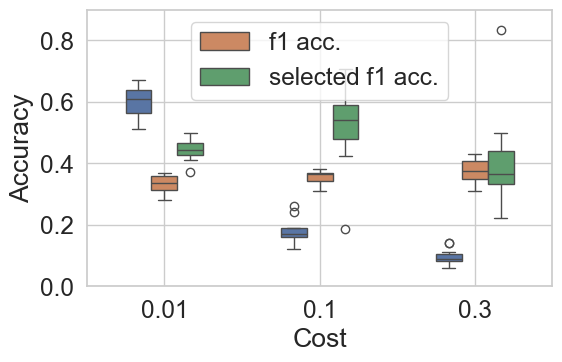

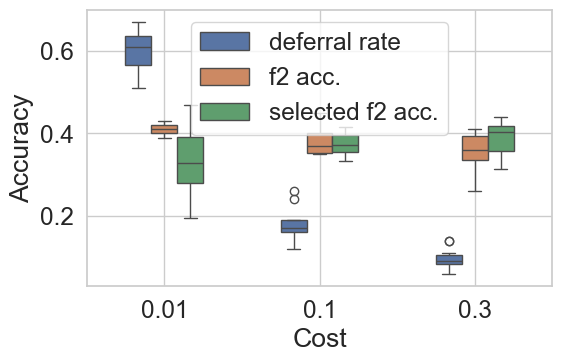

In [441]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.set_context("notebook", font_scale=1.6)
sns.boxplot(data=df_f1, x='cost', y='value', hue='model', width=0.5, linewidth=1)

# Get current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Choose the label you want to remove, e.g. 'r'
label_to_remove = 'deferral rate'

# Filter out the unwanted label and corresponding handle
filtered = [(h, l) for h, l in zip(handles, labels) if l != label_to_remove]
if filtered:
    handles, labels = zip(*filtered)
else:
    handles, labels = [], []

# Create the legend again without the unwanted label
plt.legend(handles, labels, title=None)


# Customize labels and title
plt.ylabel("Accuracy")
plt.xlabel("Cost")
plt.ylim([0,0.9])
plt.grid(True)
#plt.legend(title=None)
# Show the plot
plt.tight_layout()
plt.savefig('f1llm.pdf')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.set_context("notebook", font_scale=1.6)
sns.boxplot(data=df_f2, x='cost', y='value', hue='model', width=0.5, linewidth=1)

# Customize labels and title
plt.ylabel("Accuracy")
plt.xlabel("Cost")
plt.legend(title=None)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.savefig('f2llm.pdf')

/var/folders/fc/v4z89xy94xd8k04tsy2zrc640000gn/T/ipykernel_72265/1045896883.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_r, x='cost', y='value', hue='model', ci='sd', marker='o')


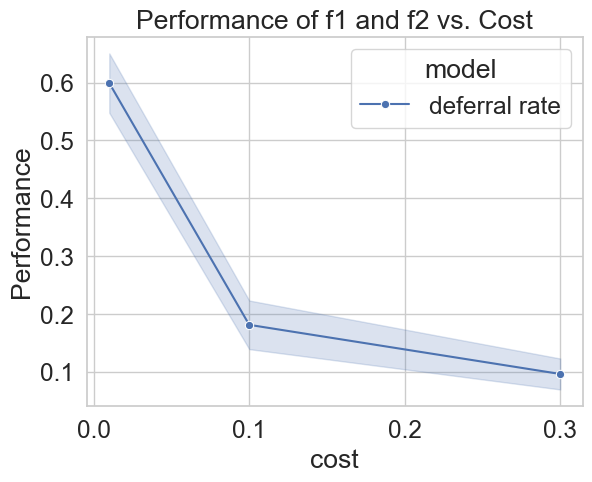

In [442]:
sns.lineplot(data=df_r, x='cost', y='value', hue='model', ci='sd', marker='o')
plt.ylabel("Performance")
plt.title("Performance of f1 and f2 vs. Cost")
plt.grid(True)
plt.show()

In [443]:
costs = [0.03,0.035,0.036,0.037]
training_log_dicts = []
for cost in costs:
    filename = os.path.join(result_path, f'new2_multi_2s_exp{cost}_k5__training_result.pkl')
    training_log_dict = load_experiment(filename)
    training_log_dicts.append(training_log_dict)

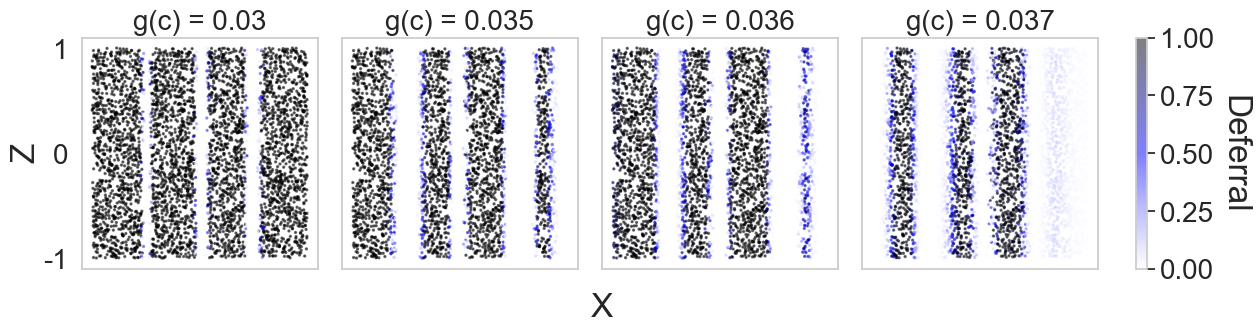

In [444]:
#figure: 3 rows, 4 columns
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
#fontsize
from matplotlib.colors import LinearSegmentedColormap
cmap_cont = matplotlib.colors.LinearSegmentedColormap.from_list(
        "Custom", ['blue', 'green'], N=20)
white_red_black = LinearSegmentedColormap.from_list(
    "white_red_black", ["#ffffff", "#0000ff", "#000000"]
)
cmap_cont = white_red_black
#cmap_cont = 'viridis'
plt.subplots_adjust(hspace=0.1, wspace=0.1)
for i, (training_log_dict) in enumerate(training_log_dicts):
    x = training_log_dict['xzy_x']
    z = training_log_dict['xzy_z']
    y = training_log_dict['xzy_s']
    num_points_max = 5000
    plt.subplot(1, 4, i+1)
    plt.title(f'g(c) = {costs[i]}', fontsize=20)
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=2, alpha=0.5)
    #plt.colorbar(ticks=range(3), label='Classes')
    plt.clim(0, 1)
    plt.yticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    #plt.xticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    plt.xticks([], [])
    #override colorbar ticks to labels "Defer", "Don't Defer"
    if i > 0:
        #remove y axis label
        plt.yticks([], [])
    #remove gridlines
    plt.grid(False)
    #cbar = plt.colorbar(sc, ticks=[0, 2])
    #cbar.ax.set_yticklabels(['Use f1', "Defer to f2"])
    

#one colorbar for all subplots
cbar = plt.colorbar(sc, ax=plt.gcf().axes, orientation='vertical', pad=0.03)
#change fontsize of colorbar ticks
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r"Deferral", rotation=270, labelpad=25, fontsize=24)
#X axis label on full plot
fig.text(0.45, -0.02, 'X', ha='center', va='center', fontsize=24)
fig.text(0.09, 0.5, 'Z', ha='center', va='center', rotation='vertical', fontsize=24)



plt.savefig(os.path.join(figure_path, 'ce.pdf'),bbox_inches = 'tight', pad_inches = 0)    
plt.show()

['deferral rate', 'f2 acc.', 'selected f2 acc.']


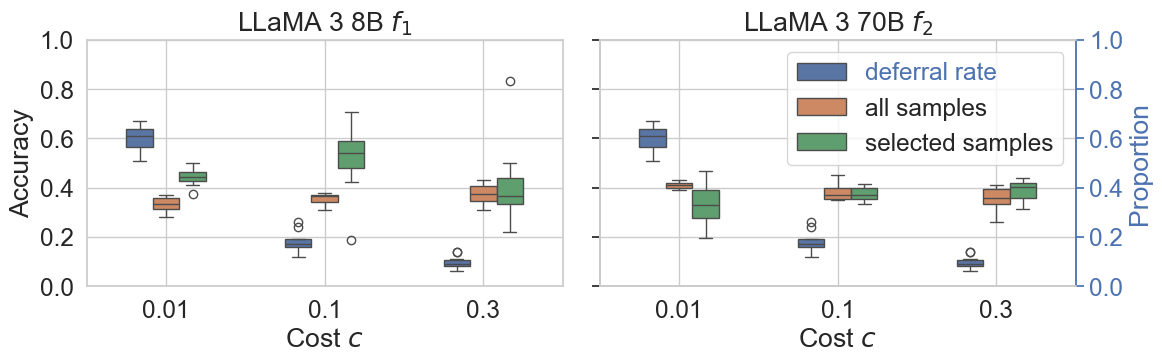

In [454]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set context and font scaling
sns.set_context("notebook", font_scale=1.6)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# First boxplot (df_f1)
sns.boxplot(data=df_f1, x='cost', y='value', hue='model', width=0.5, linewidth=1, ax=axes[0])
axes[0].set_title(r"LLaMA 3 8B $f_1$")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel(r"Cost $c$")
axes[0].grid(True)

# Remove legend from first plot
axes[0].legend([], [], frameon=False)

# Second boxplot (df_f2)
sns.boxplot(data=df_f2, x='cost', y='value', hue='model', width=0.5, linewidth=1, ax=axes[1])
axes[1].set_title(r"LLaMA 3 70B $f_2$")
axes[1].set_ylabel("")
axes[1].set_xlabel(r"Cost $c$")


# Add secondary y-axis to the right of second plot
ax2 = axes[1].twinx()
axes[1].grid(False)
ax2.set_ylabel("Proportion", color=sns.color_palette()[0])
ax2.tick_params(axis='y', colors=sns.color_palette()[0])
ax2.spines["right"].set_color(sns.color_palette()[0])
# Put grid behind everything

ax2.grid(False)         # Redraw the grid




axes[1].grid(True)


handles, labels = axes[1].get_legend_handles_labels()
label_mapping = {
    'f2 acc.': 'all samples',
    'selected f2 acc.': 'selected samples',
    'deferral rate': 'deferral rate'
}
print(labels)
new_labels = [label_mapping.get(label, label) for label in labels]
legend = axes[1].legend(handles, new_labels, title=None, loc='upper right')

# Change the text color for 'deferral rate'
for text, label in zip(legend.get_texts(), new_labels):
    if label == "deferral rate":
        text.set_color(sns.color_palette()[0])  # seaborn default blue

# Update legend labels

# Set common y-axis limit
axes[0].set_ylim([0, 1])



# Final adjustments and save
plt.tight_layout()
plt.savefig("llmsel.pdf")
plt.show()


